In [83]:
import os, sys
from pyspark.sql import SparkSession

sys.path.append(os.path.join(os.getcwd(), "/home/jovyan/work/src/pyspark_app"))

import session

spark = SparkSession.builder.getOrCreate()
url = session.jdbc_url()
props = session.jdbc_props()

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar arquivos GTFS
trips = spark.read.jdbc(
    url=url,
    table='bronze.trips',
    properties=props
).toPandas()

stop_times = spark.read.jdbc(
    url=url,
    table='bronze.stop_times',
    properties=props
).toPandas()

routes = spark.read.jdbc(
    url=url,
    table='bronze.routes',
    properties=props
).toPandas()


In [85]:
# Converter tempos em segundos para facilitar cálculo
def time_to_seconds(t):
    try:
        return t.hour * 3600 + t.minute * 60 + t.second
    except:
        return None

stop_times["arrival_sec"] = stop_times["arrival_time"].apply(time_to_seconds)
stop_times["departure_sec"] = stop_times["departure_time"].apply(time_to_seconds)

# stop_times

In [86]:

# Pegar primeira e última parada de cada trip_id
first_stops = stop_times.sort_values("stop_sequence").groupby("trip_id").first().reset_index()
last_stops = stop_times.sort_values("stop_sequence").groupby("trip_id").last().reset_index()

# first_stops

In [87]:

# Calcular duração: último arrival - primeiro departure
trip_durations = pd.DataFrame({
    "trip_id": first_stops["trip_id"],
    "start_time": first_stops["departure_sec"],
    "end_time": last_stops["arrival_sec"]
})
trip_durations["duration_min"] = (trip_durations["end_time"] - trip_durations["start_time"]) / 60

# trip_durations

In [88]:

# Juntar com trips e routes
trip_durations = trip_durations.merge(trips[["trip_id","route_id"]], on="trip_id")
trip_durations = trip_durations.merge(routes[["route_id","route_short_name","route_long_name"]],
                                      on="route_id", how="left")

# Extrair hora de início (para separar picos)
trip_durations["start_hour"] = (trip_durations["start_time"] // 3600).astype(int)

# trip_durations.sort_values(by=['start_hour'], ascending=False)

In [89]:
# Selecionar as 3 rotas com mais viagens
rotas_freq = trip_durations["route_short_name"].value_counts().head(3).index.tolist()
top3 = trip_durations[trip_durations["route_short_name"].isin(rotas_freq)]

# Ordenar cada rota pelo horário de saída
top3 = top3.sort_values(["route_short_name", "start_hour"])

# top3.loc[top3['route_short_name'] == 6]



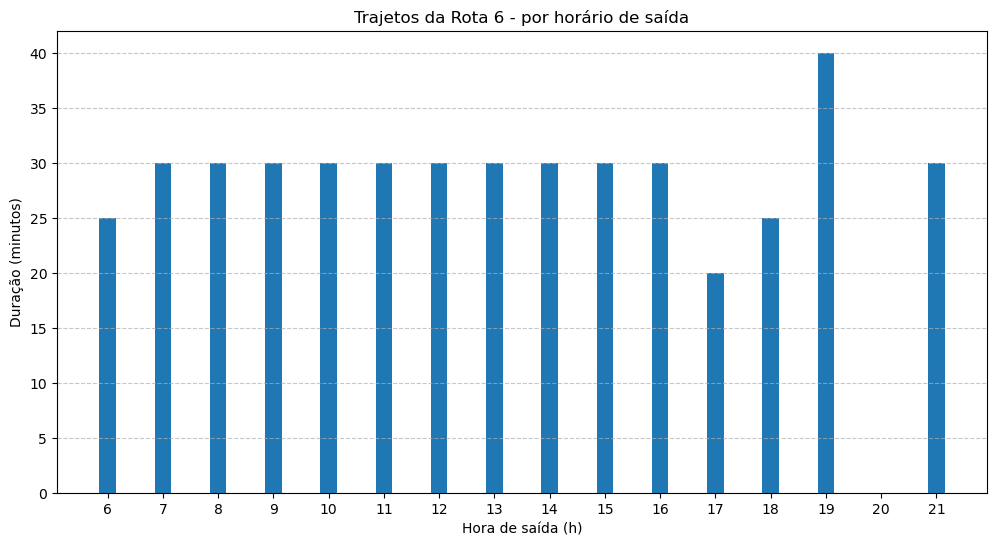

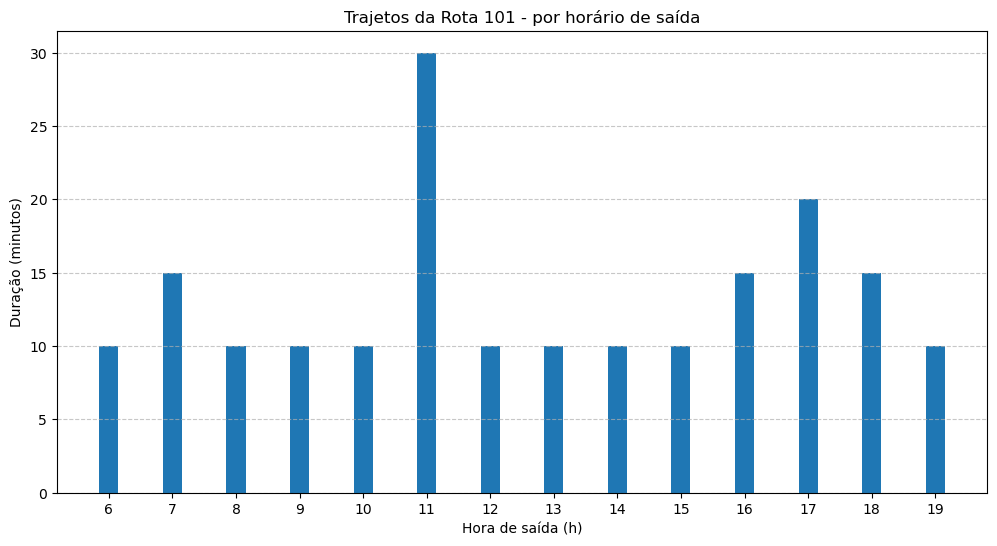

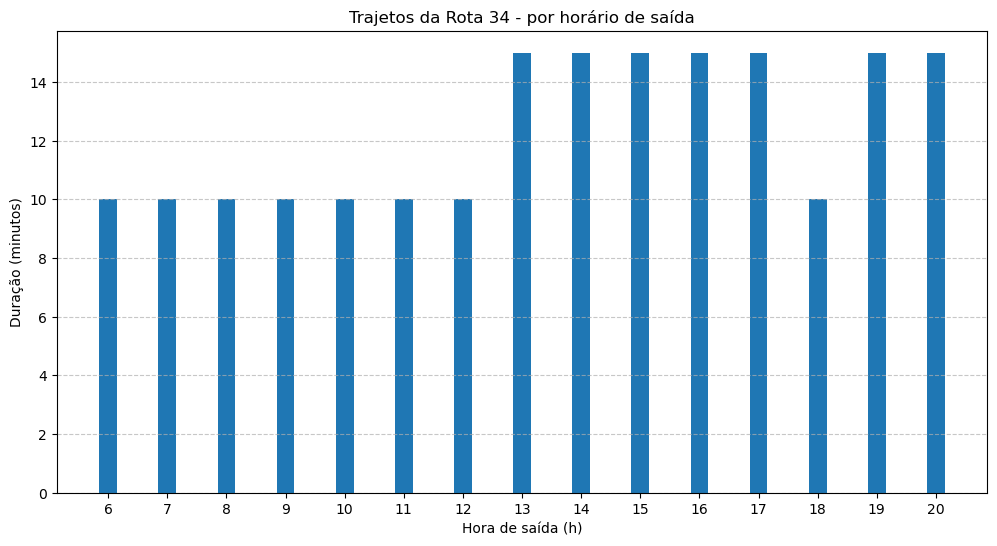

In [90]:
# Criar gráfico para cada rota, agora com hora de saída no eixo X
for rota in rotas_freq:
    subset = top3[top3["route_short_name"] == rota].copy()
    subset = subset.sort_values("start_hour")

    # eixo X = hora real de início (convertido para horas)
    x_vals = subset["start_hour"]  # transforma segundos em horas
    y_vals = subset["duration_min"]

    plt.figure(figsize=(12,6))
    plt.bar(x_vals, y_vals, width=0.3)
    plt.title(f"Trajetos da Rota {rota} - por horário de saída")
    plt.xlabel("Hora de saída (h)")
    plt.ylabel("Duração (minutos)")
    plt.xticks(range(int(x_vals.min()), int(x_vals.max())+1))  # ticks inteiros nas horas
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()